# Monte Carlo: risk, option pricing and hedging for an India AI & semiconductor portfolio

**Where this follows on from.** `markowitz_frontier.ipynb` chose portfolio weights using mean-variance optimisation. It answered *what should I hold?* and showed that the optimiser's predictions were far too optimistic out of sample.

This notebook answers three different questions about those same portfolios:

1. **What could happen next?** Simulate thousands of possible futures and measure the downside: Value at Risk, Expected Shortfall, drawdowns and the probability of losing money.
2. **Is the model honest?** Compare the model's VaR with the VaR implied by actual history, then count how often real losses in the test period broke it.
3. **What would insurance cost?** Price options by simulation (checked against Black-Scholes), compute the Greeks, hedge the portfolio with puts, and simulate delta hedging a short option.

**Why Monte Carlo.** Markowitz gives one expected return and one volatility. Those two numbers describe the whole distribution only if returns are normal and you only care about the average. Simulation gives the full distribution of outcomes, handles path-dependent questions like drawdowns and Asian options, and prices things that have no formula. The cost is accuracy: the error falls only as $1/\sqrt{N}$, so precision is bought with computation.

**How to run:** click **Run All**, or run cells one at a time with **Shift + Enter**. The whole notebook takes a couple of minutes.

## 1. Setup

Every assumption lives in this one cell. The portfolios themselves are rebuilt from `portfolio.py` using the *training* period only (Sep 2023 to Aug 2025), exactly as in the first notebook, so nothing here uses information the optimiser would not have had.

In [1]:
# --- Libraries ------------------------------------------------------------
import numpy as np                      # maths with vectors and matrices
import pandas as pd                     # tables of data (like Excel sheets)
import matplotlib.pyplot as plt         # charts
import matplotlib.ticker as mtick       # formats chart axes as percentages

import portfolio as pf                  # notebook 1's engine (weights)
import simulation as sim                # this notebook's engine (Monte Carlo)

pd.set_option("display.float_format", "{:.4f}".format)

# --- Assumptions -----------------------------------------------------------
TICKERS = ["HCLTECH.NS", "TATAELXSI.NS", "KAYNES.NS", "CGPOWER.NS",
           "DIXON.NS", "NETWEB.NS", "E2E.NS", "TATACOMM.NS"]
BENCHMARK = "^NSEI"                  # Nifty 50: benchmark AND hedging instrument
NAMES = {t: t.replace(".NS", "") for t in TICKERS}

START, END = "2023-09-01", "2026-09-17"
SPLIT_DATE = "2025-09-01"            # train / test split, as in notebook 1

RF = 0.07                            # 10-year G-Sec yield
EQUITY_PREMIUM = 0.055               # extra return expected from equities

# Simulation settings
N_PATHS = 20_000                     # simulated futures per portfolio
HORIZON_YEARS = 1.0                  # how far ahead we look
N_STEPS = 252                        # daily steps
INITIAL_VALUE = 1_000_000            # Rs 10 lakh invested
SEED = 42                            # fixes the random numbers (reproducible)

# Option settings
STRIKE_PCT = 0.95                    # protective puts 5% out of the money

In [2]:
# --- Chart style -----------------------------------------------------------
# Identical to notebook 1, so the two sets of charts look like one project.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
          "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, INK_2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE = "#e1e0d9", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK_2,
    "axes.titlecolor": INK, "axes.titlesize": 13,
    "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "legend.frameon": False, "lines.linewidth": 2,
    "font.family": ["Segoe UI", "DejaVu Sans"], "figure.dpi": 110,
})

def pct_axis(ax, which="both"):
    # Show axis numbers as percentages (0.25 -> 25%).
    if which in ("x", "both"):
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
    if which in ("y", "both"):
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))

def rupee_axis(ax, which="x"):
    # Show axis numbers as rupees in lakhs (1,000,000 -> Rs 10.0L).
    fmt = mtick.FuncFormatter(lambda v, _: f"{v/100000:,.0f}L")
    (ax.xaxis if which == "x" else ax.yaxis).set_major_formatter(fmt)

## 2. Rebuild the portfolios from notebook 1

Three portfolios are carried forward:

| Portfolio | What it is |
|---|---|
| **GMV** | Global Minimum Variance: the lowest-risk mix, ignoring expected returns |
| **Max Sharpe** | The tangency portfolio: the best risk-adjusted return in the training sample |
| **Equal weight (1/N)** | 12.5% in each stock; no estimation at all, and hard to beat (DeMiguel, Garlappi & Uppal, 2009) |

The Nifty 50 is added as a ninth asset with a **weight of zero**. It is not held, but it must be simulated alongside the stocks so that the index put in section 7 moves with the portfolio in a realistic way. That correlation is the whole question in index hedging.

In [3]:
# Prices for the eight stocks and the Nifty, from the cached CSVs.
prices = pf.download_prices(TICKERS, START, END, cache_file="data/prices.csv")
prices = prices.rename(columns=NAMES).dropna()

bench = pf.download_prices([BENCHMARK], START, END, cache_file="data/nifty50.csv")
bench = bench.rename(columns={BENCHMARK: "NIFTY"}).reindex(prices.index).ffill()

# One table with all nine columns: the stocks plus the index.
all_prices = prices.join(bench)

# Split into training and test exactly as before.
train_all = all_prices.loc[all_prices.index < SPLIT_DATE]
test_all = all_prices.loc[all_prices.index >= SPLIT_DATE]

train_returns = pf.compute_returns(train_all)     # nine columns
stock_returns = train_returns[prices.columns]     # eight stocks only
bench_returns = train_returns["NIFTY"]

# Markowitz inputs, estimated on the training period (stocks only).
mu_hist, Sigma = pf.annualise(stock_returns)

# The three portfolios.
w_gmv = pf.min_variance_portfolio(mu_hist, Sigma)
w_tan = pf.max_sharpe_portfolio(mu_hist, Sigma, RF)
w_eq = pd.Series(1 / len(prices.columns), index=prices.columns)

PORTFOLIOS = {"GMV": w_gmv, "Max Sharpe": w_tan, "Equal weight": w_eq}

display(pd.DataFrame(PORTFOLIOS).style.format("{:.1%}"))

Loading cached prices from data/prices.csv
Loading cached prices from data/nifty50.csv


,GMV,Max Sharpe,Equal weight
HCLTECH,40.0%,0.0%,12.5%
TATAELXSI,16.6%,0.0%,12.5%
KAYNES,0.0%,10.0%,12.5%
CGPOWER,8.8%,0.0%,12.5%
DIXON,5.5%,42.6%,12.5%
NETWEB,0.0%,5.7%,12.5%
E2E,5.3%,41.7%,12.5%
TATACOMM,23.8%,0.0%,12.5%


## 3. Which expected returns should the simulation use?

This choice matters more than any other in the notebook, and it is where most Monte Carlo write-ups quietly go wrong.

Simulated futures drift at whatever expected return you feed in. Notebook 1 estimated the Max Sharpe portfolio's expected return at **84% a year** from two years of data covering a strong AI rally. Simulating with that number would produce a cloud of futures in which almost everything makes money, and a VaR that looks reassuringly small — not because the portfolio is safe, but because the input was a sample average mistaken for a forecast. Chopra & Ziemba (1993) found that errors in expected returns do roughly **ten times** the damage of errors in variances.

So the notebook offers three drifts and defaults to the second:

| Drift | Definition | Comment |
|---|---|---|
| `historical` | average past return $\times$ 252 | What notebook 1 used. Shown so the distortion is visible. |
| `capm` **(default)** | $r_f + \beta_i \times \text{ERP}$ | Forward-looking. Asks how much market risk a stock carries, not what it happened to return. |
| `flat` | $r_f + \text{ERP}$ for every stock | Removes stock-specific forecasts entirely; differences then come only from risk and correlation. |

Note what does **not** change between them: the covariance matrix $\Sigma$. Volatility is estimated far more reliably than mean returns, so it is kept as estimated in every case.

In [4]:
# Betas against the Nifty, used for CAPM returns AND for sizing the index put.
betas = sim.compute_betas(stock_returns, bench_returns)

mu_capm, _ = sim.capm_drift(stock_returns, bench_returns, RF, EQUITY_PREMIUM)
mu_flat = sim.flat_drift(prices.columns, RF, EQUITY_PREMIUM)

drift_options = pd.DataFrame({
    "Beta": betas,
    "Historical": mu_hist,
    "CAPM": mu_capm,
    "Flat": mu_flat,
})
display(drift_options.style.format({"Beta": "{:.2f}", "Historical": "{:.1%}",
                                    "CAPM": "{:.1%}", "Flat": "{:.1%}"}))

# What each drift implies for the portfolios we are about to simulate.
implied = pd.DataFrame({
    name: {col: float(w @ drift_options[col][w.index])
           for col in ["Historical", "CAPM", "Flat"]}
    for name, w in PORTFOLIOS.items()
}).T
print("Expected annual return implied for each portfolio:")
display(implied.style.format("{:.1%}"))

,Beta,Historical,CAPM,Flat
HCLTECH,0.88,17.3%,11.8%,12.5%
TATAELXSI,0.91,-11.4%,12.0%,12.5%
KAYNES,1.45,70.3%,15.0%,12.5%
CGPOWER,1.07,33.1%,12.9%,12.5%
DIXON,1.37,69.1%,14.6%,12.5%
NETWEB,1.24,63.0%,13.8%,12.5%
E2E,0.56,105.2%,10.1%,12.5%
TATACOMM,1.03,-4.2%,12.7%,12.5%


Expected annual return implied for each portfolio:


,Historical,CAPM,Flat
GMV,16.3%,12.2%,12.5%
Max Sharpe,83.9%,12.7%,12.5%
Equal weight,42.8%,12.9%,12.5%


In [5]:
# --- Choose the drift used for the rest of the notebook --------------------
# Change DRIFT to "historical" or "flat" to see how much the risk numbers
# depend on this one assumption.
DRIFT = "capm"

mu_sim = {"historical": mu_hist, "capm": mu_capm, "flat": mu_flat}[DRIFT]

# The Nifty is simulated too, so it needs an expected return of its own.
# By definition the market's beta is 1, so the CAPM gives rf + ERP.
mu_all = mu_sim.copy()
mu_all["NIFTY"] = RF + EQUITY_PREMIUM if DRIFT != "historical" else \
                  bench_returns.mean() * 252

# Covariance of all nine assets (stocks and index together), so that the
# index moves realistically against the basket in the simulation.
Sigma_all = train_returns.cov() * 252
mu_all = mu_all[Sigma_all.columns]

print(f"Drift in use: {DRIFT}")
print(f"Nifty: expected return {mu_all['NIFTY']:.1%}, "
      f"volatility {np.sqrt(Sigma_all.loc['NIFTY','NIFTY']):.1%}")
print("\nPortfolio betas (hedge ratios for the index put in section 7):")
for name, w in PORTFOLIOS.items():
    print(f"  {name:<14} beta {sim.portfolio_beta(w, betas):.2f}")

Drift in use: capm
Nifty: expected return 12.5%, volatility 13.3%

Portfolio betas (hedge ratios for the index put in section 7):
  GMV            beta 0.95
  Max Sharpe     beta 1.04
  Equal weight   beta 1.07


## 4. Simulating the portfolios

Each path is one possible year, built from correlated **geometric Brownian motion**:

$$S(t+\Delta t) = S(t)\exp\left[\left(\mu - \tfrac{1}{2}\sigma^2\right)\Delta t + \sigma\sqrt{\Delta t}\,Z\right]$$

Two details that are easy to get wrong:

- **The $-\tfrac{1}{2}\sigma^2$ term.** Without it the simulated average price drifts above $e^{\mu T}$, because the average of an exponential is not the exponential of the average (Jensen's inequality). With it, $E[S_T/S_0] = e^{\mu T}$ exactly.
- **Correlation.** Independent random draws $Z$ are turned into correlated ones by multiplying by the Cholesky factor $L$, where $LL' = \Sigma$. This is the matrix version of multiplying a standard normal by $\sigma$. Ignoring it would simulate eight unrelated stocks and overstate diversification badly.

The portfolios are **bought and held**, with no rebalancing, matching notebook 1's out-of-sample test.

In [6]:
# Weights extended to nine assets: the Nifty gets a weight of zero.
weights_all = {name: w.reindex(Sigma_all.columns).fillna(0.0)
               for name, w in PORTFOLIOS.items()}

# Run the simulation for each portfolio. Same seed for all three, so they see
# the SAME simulated futures and any difference is due to the weights alone.
sims = {
    name: sim.simulate_portfolio(mu_all, Sigma_all, w,
                                 horizon_years=HORIZON_YEARS, n_steps=N_STEPS,
                                 n_paths=N_PATHS, initial_value=INITIAL_VALUE,
                                 seed=SEED)
    for name, w in weights_all.items()
}

print(f"{N_PATHS:,} paths x {N_STEPS} days simulated for each portfolio.")

# Sanity check: the simulated average growth should match the expected return
# we asked for, exp(mu*T) - 1. If these disagree, the drift is wrong.
print("\nCheck that the simulation reproduces its own inputs:")
for name, s in sims.items():
    realised = s["values"][:, -1].mean() / s["initial"] - 1
    intended = np.exp(float(weights_all[name] @ mu_all) * HORIZON_YEARS) - 1
    print(f"  {name:<14} simulated mean {realised:+.2%}  vs intended {intended:+.2%}")

20,000 paths x 252 days simulated for each portfolio.

Check that the simulation reproduces its own inputs:
  GMV            simulated mean +12.94%  vs intended +12.99%
  Max Sharpe     simulated mean +13.65%  vs intended +13.54%
  Equal weight   simulated mean +13.77%  vs intended +13.72%


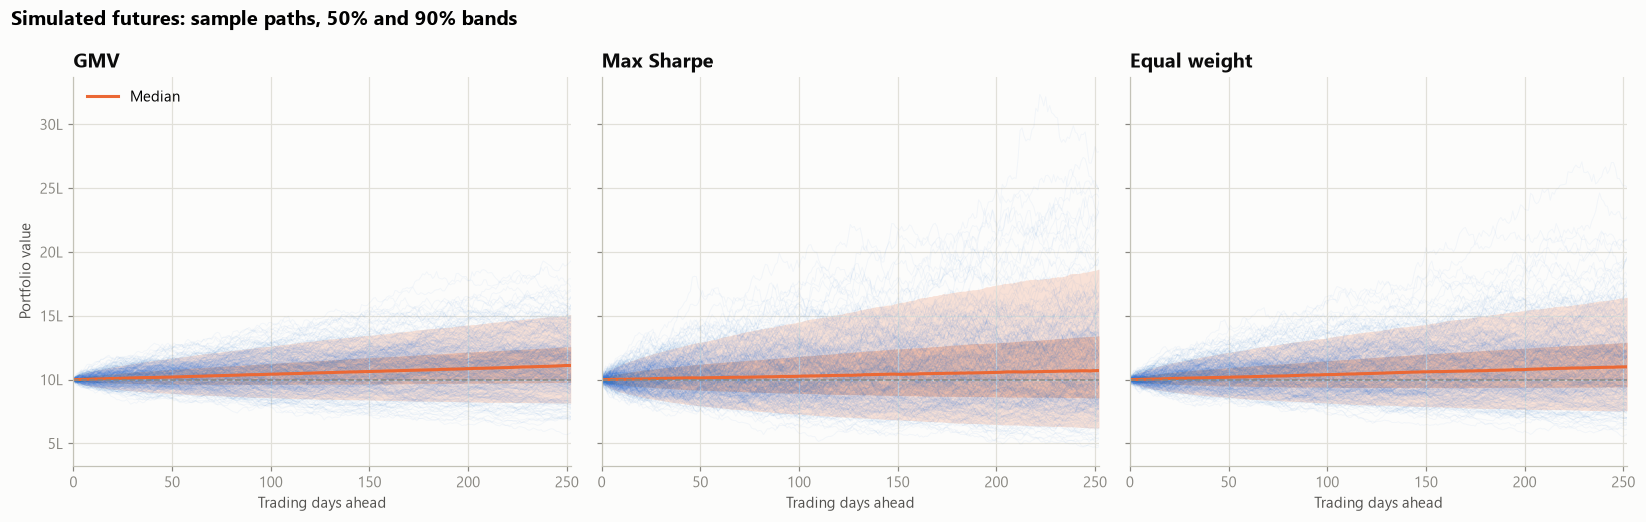

In [7]:
# --- Fan chart: 300 sample paths plus the percentile bands -----------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
days = np.arange(N_STEPS + 1)

for ax, (name, s) in zip(axes, sims.items()):
    values = s["values"]

    # A thin sample of individual paths, to show what one future looks like.
    for i in range(0, 300):
        ax.plot(days, values[i], color=SERIES[0], alpha=0.05, linewidth=0.6)

    # Percentile bands across ALL paths: the shape of the distribution.
    for lo, hi, shade in [(5, 95, 0.18), (25, 75, 0.28)]:
        ax.fill_between(days,
                        np.percentile(values, lo, axis=0),
                        np.percentile(values, hi, axis=0),
                        color=SERIES[1], alpha=shade, linewidth=0)
    ax.plot(days, np.percentile(values, 50, axis=0), color=SERIES[1],
            linewidth=2, label="Median")
    ax.axhline(INITIAL_VALUE, color=MUTED, linestyle="--", linewidth=1)

    ax.set_title(name)
    ax.set_xlabel("Trading days ahead")
    ax.set_xlim(0, N_STEPS)
    rupee_axis(ax, "y")

axes[0].set_ylabel("Portfolio value")
axes[0].legend(loc="upper left")
fig.suptitle("Simulated futures: sample paths, 50% and 90% bands",
             x=0.005, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/mc_fan_chart.png", dpi=200)
plt.show()

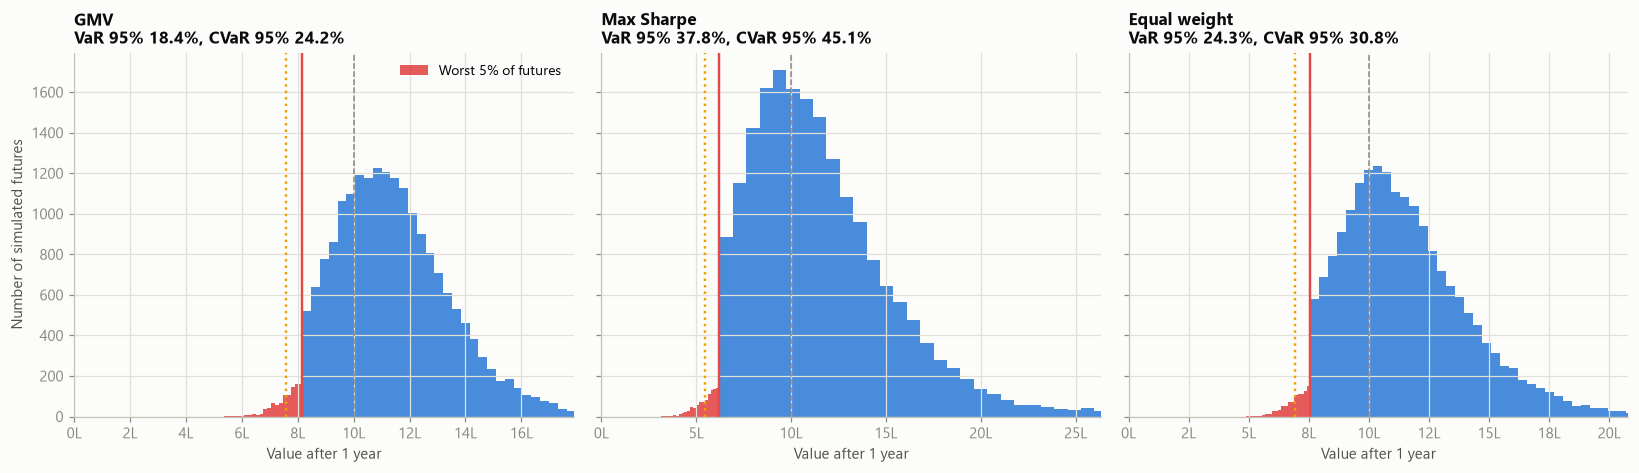

In [8]:
# --- Distribution of the final value, with VaR and CVaR marked -------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharey=True)

for ax, (name, s) in zip(axes, sims.items()):
    terminal = s["values"][:, -1]
    var95 = sim.value_at_risk(terminal, s["initial"], 0.95)
    cvar95 = sim.conditional_value_at_risk(terminal, s["initial"], 0.95)

    # The 5% worst outcomes are drawn in a separate colour: that is the tail
    # VaR and CVaR are describing.
    cut = s["initial"] * (1 - var95)
    ax.hist(terminal[terminal >= cut], bins=60, color=SERIES[0], alpha=0.85)
    ax.hist(terminal[terminal < cut], bins=20, color=SERIES[7], alpha=0.9,
            label="Worst 5% of futures")

    ax.axvline(s["initial"], color=MUTED, linestyle="--", linewidth=1)
    ax.axvline(cut, color=SERIES[7], linewidth=1.6)
    ax.axvline(s["initial"] * (1 - cvar95), color=SERIES[3], linewidth=1.6,
               linestyle=":")
    ax.set_title(f"{name}\nVaR 95% {var95:.1%}, CVaR 95% {cvar95:.1%}",
                 fontsize=11)
    ax.set_xlabel("Value after 1 year")
    rupee_axis(ax, "x")
    ax.set_xlim(0, np.percentile(terminal, 99.5))

axes[0].set_ylabel("Number of simulated futures")
axes[0].legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("outputs/mc_distributions.png", dpi=200)
plt.show()

## 5. Risk metrics

Four numbers, and what each one actually says:

- **VaR (95%)** — the loss that is exceeded in the worst 5% of futures. It is a *threshold*, not a worst case, and it says nothing about how bad things get beyond it.
- **CVaR / Expected Shortfall (95%)** — the *average* loss in that worst 5%. It answers "and if it does go wrong, how wrong?". Unlike VaR it is coherent (merging two portfolios can never increase it), which is why the Basel framework moved from VaR to Expected Shortfall for market risk.
- **Maximum drawdown** — the worst peak-to-trough fall *during* the year. Terminal VaR only looks at the finish line; an investor lives through the journey, and a 40% mid-year fall is what triggers people to sell at the bottom.
- **Probability of loss** — the least technical number here, and often the most useful one in a conversation with a client.

The mean sits above the median in every case. That is the lognormal distribution at work: a few very large gains pull the average up, while the typical outcome is lower. Quoting the mean alone flatters the portfolio.

In [9]:
risk_table = pd.DataFrame({
    name: sim.simulation_summary(s, RF, confidence_levels=(0.95, 0.99))
    for name, s in sims.items()
}).T

display(risk_table.style.format("{:.2%}").format(
    "{:.0%}", subset=["P(loss)", "P(beat risk-free)"]))

,Mean return,Median return,Std dev of return,5th percentile,95th percentile,VaR 95%,CVaR 95%,VaR 99%,CVaR 99%,Median max drawdown,Worst max drawdown,P(loss),P(beat risk-free)
GMV,12.94%,11.08%,21.27%,-18.35%,50.94%,18.35%,24.15%,28.07%,31.74%,-15.08%,-50.61%,29%,58%
Max Sharpe,13.65%,7.03%,39.75%,-37.82%,86.53%,37.82%,45.13%,49.81%,54.54%,-28.38%,-71.03%,42%,50%
Equal weight,13.77%,10.05%,27.60%,-24.35%,64.51%,24.35%,30.77%,34.96%,38.79%,-19.57%,-56.66%,34%,55%


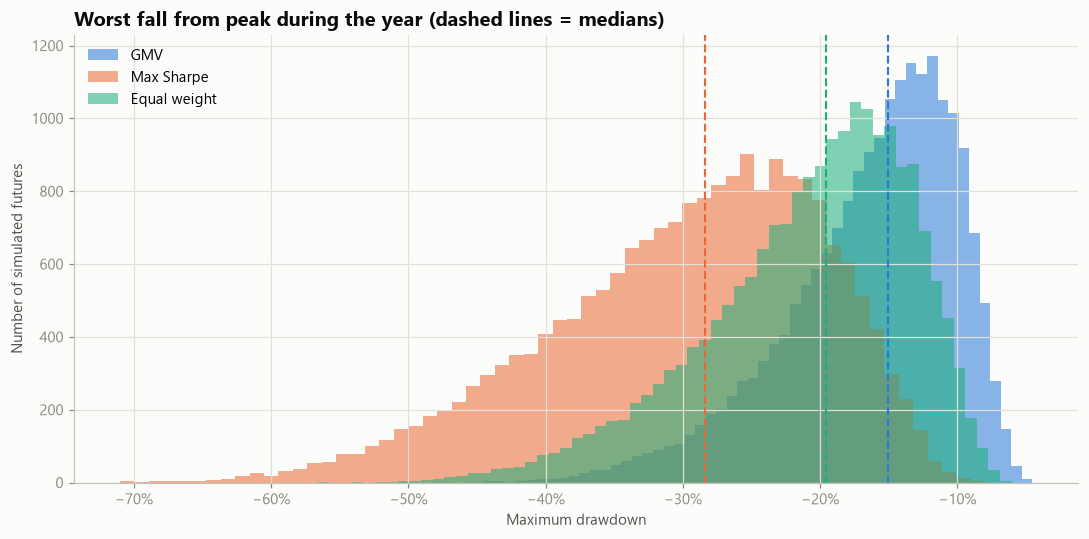

A drawdown this deep or deeper happened in ... of simulated futures:
  GMV            -20%: 24.2%    -30%:  3.5%    -40%:  0.2%


  Max Sharpe     -20%: 83.5%    -30%: 44.1%    -40%: 16.8%
  Equal weight   -20%: 47.8%    -30%: 12.6%    -40%:  1.7%


In [10]:
# --- Drawdown distributions ------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, s) in enumerate(sims.items()):
    dd = sim.max_drawdown_paths(s["values"])
    ax.hist(dd, bins=60, color=SERIES[i], alpha=0.55, label=name)
    ax.axvline(np.median(dd), color=SERIES[i], linestyle="--", linewidth=1.4)

ax.set_title("Worst fall from peak during the year (dashed lines = medians)")
ax.set_xlabel("Maximum drawdown")
ax.set_ylabel("Number of simulated futures")
pct_axis(ax, "x")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/mc_drawdowns.png", dpi=200)
plt.show()

print("A drawdown this deep or deeper happened in ... of simulated futures:")
for name, s in sims.items():
    dd = sim.max_drawdown_paths(s["values"])
    print(f"  {name:<14} -20%: {(dd <= -0.20).mean():5.1%}    "
          f"-30%: {(dd <= -0.30).mean():5.1%}    -40%: {(dd <= -0.40).mean():5.1%}")

## 6. Is the model honest?

A risk model that is never tested is decoration. GBM assumes normally distributed returns, and real equity returns have **fat tails**: crashes happen far more often than a normal distribution permits. Two checks follow.

**Check 1 — against history.** Compare the model's VaR with VaR taken straight from past returns, with no model at all (the empirical percentile of actual returns). If the historical number is larger, the model is understating the tails.

**Check 2 — against what actually happened.** Take the one-day VaR implied by the training data, then count how often the *test period* (Sep 2025 to Sep 2026, unseen by the model) produced a worse loss. At 95% confidence, about 5% of days should breach it. This is what regulators do: Basel's traffic-light test counts breaches over 250 trading days and raises a bank's capital multiplier once there are too many.

In [11]:
# Daily portfolio returns in the TRAINING period (for the historical VaR)
# and in the TEST period (for the backtest).
train_port = {name: (stock_returns * w).sum(axis=1)
              for name, w in PORTFOLIOS.items()}
test_returns = pf.compute_returns(test_all)[prices.columns]
test_port = {name: (test_returns * w).sum(axis=1)
             for name, w in PORTFOLIOS.items()}

rows = []
for name, w in PORTFOLIOS.items():
    # Model inputs for this portfolio, using the drift chosen in section 3.
    mu_p = float(w @ mu_sim)
    sigma_p = float(np.sqrt(w @ Sigma @ w))

    for horizon in (1, 10):
        for c in (0.95, 0.99):
            rows.append({
                "Portfolio": name,
                "Horizon (days)": horizon,
                "Confidence": f"{c:.0%}",
                "GBM (model)": sim.gbm_var(mu_p, sigma_p, c, horizon),
                "Historical": sim.historical_var(train_port[name], c, horizon),
            })

var_compare = pd.DataFrame(rows)
var_compare["Model / Historical"] = (var_compare["GBM (model)"]
                                     / var_compare["Historical"])
display(var_compare.style.format({"GBM (model)": "{:.2%}",
                                  "Historical": "{:.2%}",
                                  "Model / Historical": "{:.2f}"}))

,Portfolio,Horizon (days),Confidence,GBM (model),Historical,Model / Historical
0,GMV,1,95%,1.85%,1.71%,1.08
1,GMV,1,99%,2.62%,3.16%,0.83
2,GMV,10,95%,5.47%,5.73%,0.95
3,GMV,10,99%,7.80%,8.91%,0.88
4,Max Sharpe,1,95%,3.34%,3.01%,1.11
5,Max Sharpe,1,99%,4.70%,4.68%,1.00
6,Max Sharpe,10,95%,10.00%,10.00%,1.00
7,Max Sharpe,10,99%,13.95%,20.65%,0.68
8,Equal weight,1,95%,2.34%,2.34%,1.00
9,Equal weight,1,99%,3.32%,4.28%,0.77


,Portfolio,1-day VaR,Test days,Breaches,Expected,Breach rate
0,GMV,1.85%,260,19,13.0,7.31%
1,Max Sharpe,3.34%,260,15,13.0,5.77%
2,Equal weight,2.34%,260,16,13.0,6.15%


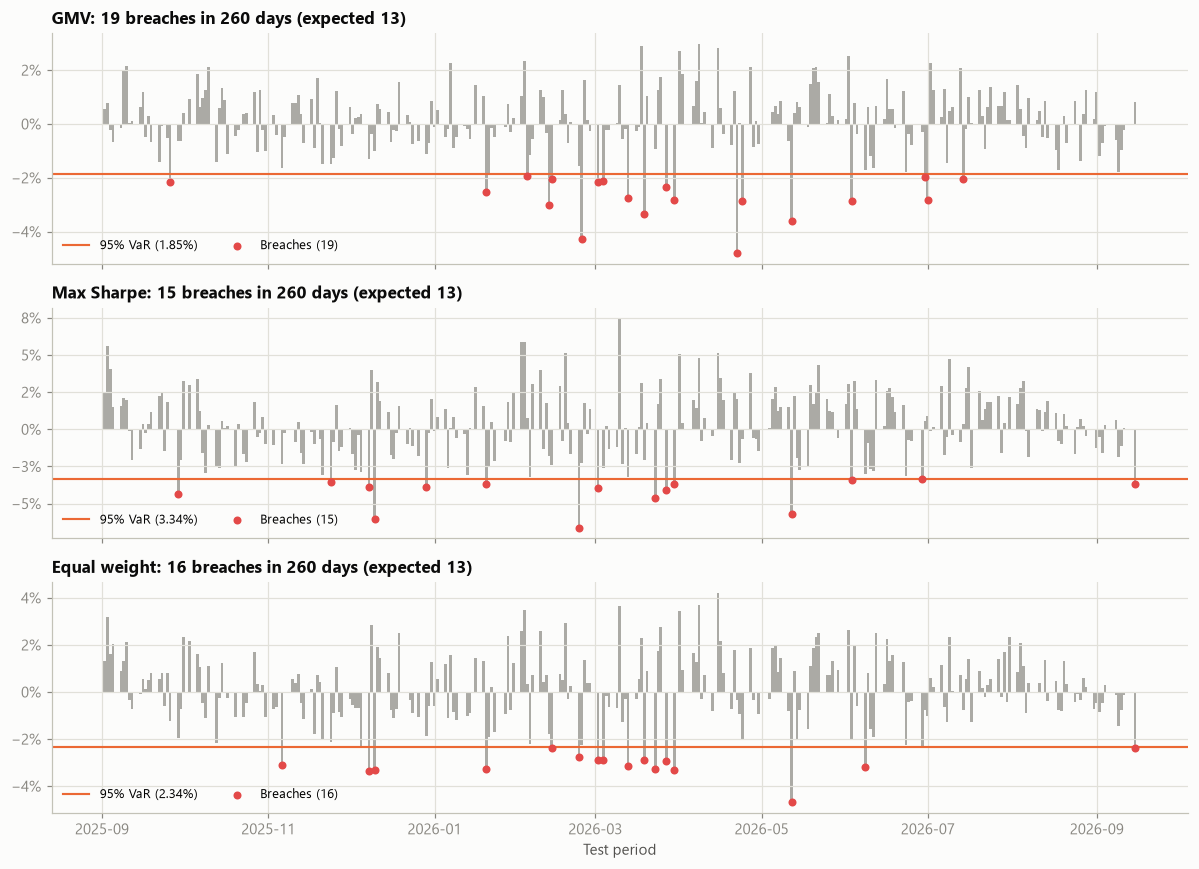

In [12]:
# --- VaR backtest on the test period ---------------------------------------
BACKTEST_CONFIDENCE = 0.95

backtest_rows = []
backtests = {}
for name, w in PORTFOLIOS.items():
    mu_p = float(w @ mu_sim)
    sigma_p = float(np.sqrt(w @ Sigma @ w))
    var_1d = sim.gbm_var(mu_p, sigma_p, BACKTEST_CONFIDENCE, 1)

    bt = sim.var_backtest(test_port[name], var_1d, BACKTEST_CONFIDENCE)
    backtests[name] = bt
    backtest_rows.append({
        "Portfolio": name,
        "1-day VaR": var_1d,
        "Test days": bt["n_days"],
        "Breaches": bt["n_breaches"],
        "Expected": bt["expected_breaches"],
        "Breach rate": bt["breach_rate"],
    })

display(pd.DataFrame(backtest_rows).style.format({
    "1-day VaR": "{:.2%}", "Expected": "{:.1f}", "Breach rate": "{:.2%}"}))

# Chart: daily test-period returns with the VaR line and the breaches marked.
fig, axes = plt.subplots(len(PORTFOLIOS), 1, figsize=(11, 8), sharex=True)
for ax, (name, bt) in zip(axes, backtests.items()):
    r = test_port[name]
    ax.bar(r.index, r, color=MUTED, width=1.0, alpha=0.7)
    ax.axhline(-bt["var_1day"], color=SERIES[1], linewidth=1.4,
               label=f"95% VaR ({bt['var_1day']:.2%})")
    ax.scatter(bt["breach_dates"], bt["breach_returns"], color=SERIES[7],
               s=18, zorder=3, label=f"Breaches ({bt['n_breaches']})")
    ax.set_title(f"{name}: {bt['n_breaches']} breaches in {bt['n_days']} days "
                 f"(expected {bt['expected_breaches']:.0f})", fontsize=11)
    ax.legend(loc="lower left", fontsize=8.5, ncol=2)
    pct_axis(ax, "y")
axes[-1].set_xlabel("Test period")
plt.tight_layout()
plt.savefig("outputs/mc_var_backtest.png", dpi=200)
plt.show()

## 7. Option pricing by Monte Carlo

The recipe never changes:

1. Simulate price paths under the **risk-neutral measure**, where the drift is the risk-free rate $r$.
2. Work out the payoff on each path.
3. Average the payoffs and discount at $e^{-rT}$.

**Why the drift is $r$ and not $\mu$.** This is the single most important idea in derivatives pricing and the easiest to get wrong. An option can be replicated by continuously trading the stock and cash. Two portfolios with identical payoffs must have identical prices, or there is an arbitrage — and that argument never refers to the stock's expected return. So $\mu$ drops out: a stock expected to return 40% and one expected to return 7% have the same option price if their volatilities match. The stock's real drift reappears only in section 9, where we simulate what actually happens to a hedger's P&L.

**The volatility used.** Implied volatility from NSE option chains is not freely available, so every option here is priced with the stock's **historical volatility** from the training period. Real desks would use implied volatility, and the gap between the two is precisely what section 9 explores.

A **standard error** is reported with every simulated price. The price is an average of random payoffs, so it is itself random; quoting it without an error bar is like quoting a poll with no margin of error.

In [13]:
# Price options on the largest holding of the Max Sharpe portfolio, so the
# option section connects to the portfolio section.
UNDERLYING = w_tan.idxmax()
S0 = float(prices[UNDERLYING].loc[:SPLIT_DATE].iloc[-1])
SIGMA = float(np.sqrt(Sigma.loc[UNDERLYING, UNDERLYING]))
K = round(S0)                # at the money
T = 1.0

print(f"Underlying     : {UNDERLYING} (largest Max Sharpe holding, "
      f"{w_tan[UNDERLYING]:.0%})")
print(f"Spot price     : Rs {S0:,.2f}")
print(f"Strike         : Rs {K:,.0f} (at the money)")
print(f"Volatility     : {SIGMA:.1%} a year (historical, training period)")
print(f"Risk-free rate : {RF:.1%},  maturity {T:.0f} year")

# European call and put: Monte Carlo against the exact Black-Scholes price.
rows = []
for kind, opt in [("european_call", "call"), ("european_put", "put")]:
    mc = sim.monte_carlo_option(S0, K, T, RF, SIGMA, kind,
                                n_paths=200_000, seed=SEED)
    bs = sim.black_scholes_price(S0, K, T, RF, SIGMA, opt)
    rows.append({
        "Option": kind.replace("_", " ").title(),
        "Monte Carlo": mc["price"], "Std error": mc["stderr"],
        "95% CI": f"[{mc['ci_low']:,.2f}, {mc['ci_high']:,.2f}]",
        "Black-Scholes": bs,
        "Difference": mc["price"] - bs,
    })
display(pd.DataFrame(rows).style.format({
    "Monte Carlo": "{:,.2f}", "Std error": "{:,.3f}",
    "Black-Scholes": "{:,.2f}", "Difference": "{:+,.3f}"}))

# Put-call parity is an arbitrage identity, not a model result: it must hold
# exactly for the closed-form prices.
call = sim.black_scholes_price(S0, K, T, RF, SIGMA, "call")
put = sim.black_scholes_price(S0, K, T, RF, SIGMA, "put")
print(f"\nPut-call parity check:  C - P = {call - put:,.4f}   "
      f"S - Ke^(-rT) = {S0 - K*np.exp(-RF*T):,.4f}")

Underlying     : DIXON (largest Max Sharpe holding, 43%)
Spot price     : Rs 17,574.18
Strike         : Rs 17,574 (at the money)
Volatility     : 38.8% a year (historical, training period)
Risk-free rate : 7.0%,  maturity 1 year


,Option,Monte Carlo,Std error,95% CI,Black-Scholes,Difference
0,European Call,"3,255.60",12.198,"[3,231.70, 3,279.51]","3,246.03",+9.578
1,European Put,"2,062.98",6.160,"[2,050.90, 2,075.05]","2,057.74",+5.240



Put-call parity check:  C - P = 1,188.2907   S - Ke^(-rT) = 1,188.2907


### 7.1 Convergence: how many paths are enough?

Monte Carlo error falls as $1/\sqrt{N}$. Multiplying the number of paths by 100 improves accuracy only by a factor of 10 — this is the method's central weakness, and the reason variance-reduction techniques exist.

The chart below plots the simulated price against the exact Black-Scholes price, with the 95% confidence interval as a band. Two things to look for: the band narrows as $1/\sqrt{N}$, and the exact price stays inside it, which is the evidence that the estimator is unbiased rather than merely precise.

,Paths,MC price,Std error,CI low,CI high,Black-Scholes,Error,Inside CI
0,100,"3,644.465",687.750,"2,296.475","4,992.456","3,246.027",+398.438,True
1,500,"3,148.683",255.379,"2,648.141","3,649.225","3,246.027",-97.345,True
2,1000,"3,141.733",166.725,"2,814.951","3,468.515","3,246.027",-104.294,True
3,5000,"3,208.139",73.898,"3,063.299","3,352.980","3,246.027",-37.888,True
4,10000,"3,198.458",53.810,"3,092.990","3,303.926","3,246.027",-47.569,True
5,50000,"3,245.612",24.127,"3,198.322","3,292.902","3,246.027",-0.415,True
6,100000,"3,238.493",16.986,"3,205.200","3,271.786","3,246.027",-7.535,True
7,500000,"3,233.299",7.614,"3,218.376","3,248.222","3,246.027",-12.728,True


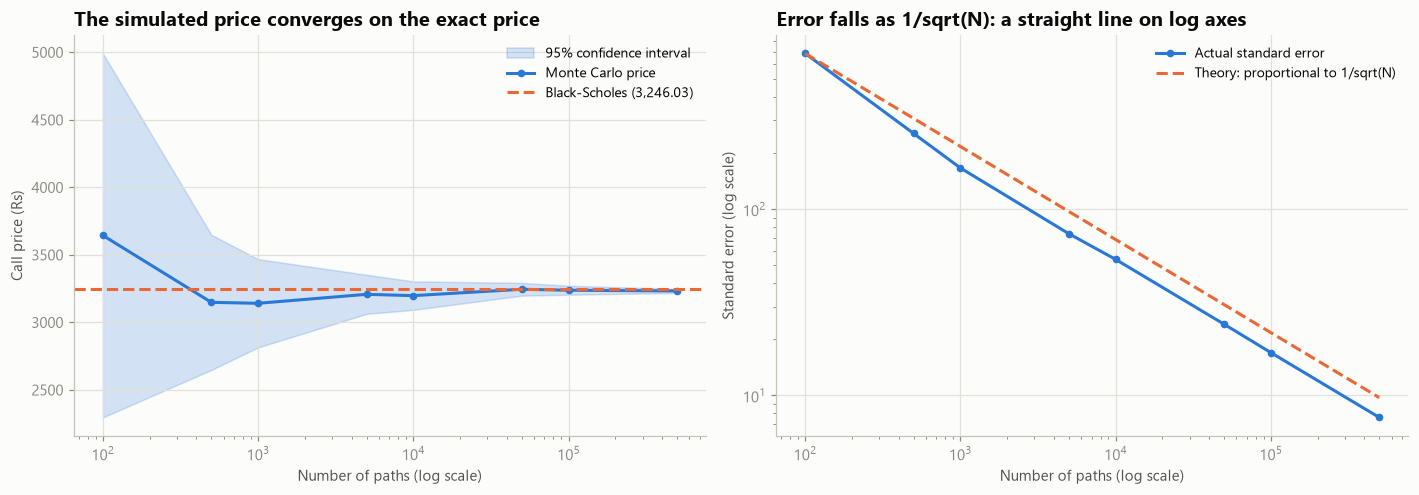

In [14]:
conv = sim.convergence_study(S0, K, T, RF, SIGMA, "european_call",
                             path_counts=(100, 500, 1_000, 5_000, 10_000,
                                          50_000, 100_000, 500_000), seed=SEED)
display(conv.style.format({"MC price": "{:,.3f}", "Std error": "{:,.3f}",
                           "CI low": "{:,.3f}", "CI high": "{:,.3f}",
                           "Black-Scholes": "{:,.3f}", "Error": "{:+,.3f}"}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# Left: the price and its confidence band closing in on the exact answer.
ax = axes[0]
exact = conv["Black-Scholes"].iloc[0]
ax.fill_between(conv["Paths"], conv["CI low"], conv["CI high"],
                color=SERIES[0], alpha=0.2, label="95% confidence interval")
ax.plot(conv["Paths"], conv["MC price"], color=SERIES[0], marker="o",
        markersize=4, label="Monte Carlo price")
ax.axhline(exact, color=SERIES[1], linestyle="--",
           label=f"Black-Scholes ({exact:,.2f})")
ax.set_xscale("log")
ax.set_xlabel("Number of paths (log scale)")
ax.set_ylabel(f"Call price (Rs)")
ax.set_title("The simulated price converges on the exact price")
ax.legend(fontsize=9)

# Right: the standard error against the theoretical 1/sqrt(N) line.
ax = axes[1]
ax.plot(conv["Paths"], conv["Std error"], color=SERIES[0], marker="o",
        markersize=4, label="Actual standard error")
reference = conv["Std error"].iloc[0] * np.sqrt(
    conv["Paths"].iloc[0] / conv["Paths"])
ax.plot(conv["Paths"], reference, color=SERIES[1], linestyle="--",
        label="Theory: proportional to 1/sqrt(N)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Number of paths (log scale)")
ax.set_ylabel("Standard error (log scale)")
ax.set_title("Error falls as 1/sqrt(N): a straight line on log axes")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("outputs/mc_convergence.png", dpi=200)
plt.show()

### 7.2 An Asian option: where Monte Carlo is not optional

An **Asian option** pays off on the *average* price over its life rather than the final price:

$$\text{Asian call payoff} = \max\left(\frac{1}{n}\sum_{t=1}^{n} S_t - K,\ 0\right)$$

There is no Black-Scholes formula for it. The sum of lognormal variables is not itself lognormal, so the integral has no closed form, and simulation is the standard approach.

Two properties follow from averaging, and both show up in the numbers below:

- **It is cheaper than the European option.** An average wanders less than an endpoint: the effective volatility is roughly $\sigma/\sqrt{3}$ for a continuous average.
- **It is harder to manipulate.** A single closing price can be pushed around near expiry; an average over the whole period cannot. This is why Asians dominate commodity and currency hedging, where a treasurer hedging monthly fuel purchases wants the average anyway.

European call : Rs  3,241.53  (+/- 33.73)
Asian call    : Rs  1,815.20  (+/- 17.66)

The Asian option costs 44% less.
Rule of thumb: averaging cuts effective volatility to about sigma/sqrt(3) = 22.4%
European call repriced at that volatility: Rs 2,180.38  (close to the simulated Asian price)


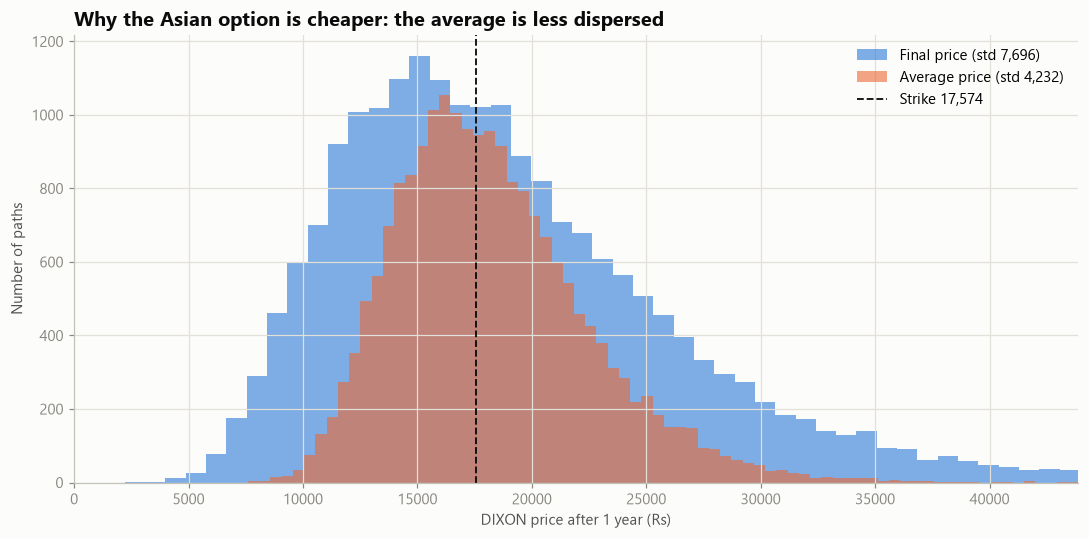

In [15]:
asian = sim.monte_carlo_option(S0, K, T, RF, SIGMA, "asian_call",
                               n_paths=100_000, n_steps=252, seed=SEED)
european = sim.monte_carlo_option(S0, K, T, RF, SIGMA, "european_call",
                                  n_paths=100_000, seed=SEED)

print(f"European call : Rs {european['price']:>9,.2f}  "
      f"(+/- {1.96*european['stderr']:,.2f})")
print(f"Asian call    : Rs {asian['price']:>9,.2f}  "
      f"(+/- {1.96*asian['stderr']:,.2f})")
print(f"\nThe Asian option costs {1 - asian['price']/european['price']:.0%} less.")
print(f"Rule of thumb: averaging cuts effective volatility to about "
      f"sigma/sqrt(3) = {SIGMA/np.sqrt(3):.1%}")
print(f"European call repriced at that volatility: Rs "
      f"{sim.black_scholes_price(S0, K, T, RF, SIGMA/np.sqrt(3), 'call'):,.2f}"
      "  (close to the simulated Asian price)")

# Payoff distributions, which show WHY the Asian is cheaper.
paths_euro = sim.simulate_asset_paths(S0, RF, SIGMA, T, 252, 20_000, SEED)
final_prices = paths_euro[:, -1]
average_prices = paths_euro[:, 1:].mean(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(final_prices, bins=80, color=SERIES[0], alpha=0.6,
        label=f"Final price (std {final_prices.std():,.0f})")
ax.hist(average_prices, bins=80, color=SERIES[1], alpha=0.6,
        label=f"Average price (std {average_prices.std():,.0f})")
ax.axvline(K, color=INK, linestyle="--", linewidth=1.2, label=f"Strike {K:,.0f}")
ax.set_title("Why the Asian option is cheaper: the average is less dispersed")
ax.set_xlabel(f"{UNDERLYING} price after 1 year (Rs)")
ax.set_ylabel("Number of paths")
ax.set_xlim(0, np.percentile(final_prices, 99))
ax.legend()
plt.tight_layout()
plt.savefig("outputs/mc_asian.png", dpi=200)
plt.show()

## 8. The Greeks

The Greeks are the option's sensitivities: how much the price moves when one input changes. They are what a desk actually trades on, because they say how to hedge.

| Greek | Meaning | Hedging use |
|---|---|---|
| $\Delta$ | change in price per Re 1 change in the stock | shares to hold per option |
| $\Gamma$ | change in delta per Re 1 change in the stock | how often the hedge must be adjusted |
| $\nu$ (vega) | change in price per 1 point of volatility | exposure to volatility itself |
| $\Theta$ | value lost as one day passes | the cost of holding the position |
| $\rho$ | sensitivity to interest rates | usually the smallest |

Two simulation methods are used:

1. **Bump and revalue** — reprice with a slightly higher and lower input, then take the difference. The essential trick is **common random numbers**: both repricings use the *same* random draws, so simulation noise cancels between them. Without it, the difference would be mostly noise and gamma would be meaningless.
2. **Pathwise derivative** — differentiate the payoff itself. For a European call, $\frac{\partial}{\partial S_0}\max(S_T - K, 0) = \mathbb{1}_{\{S_T > K\}}\frac{S_T}{S_0}$, so delta comes out of one simulation, faster and more accurately. It needs a payoff that is differentiable almost everywhere: it works for calls and puts, but fails for a digital option, whose payoff jumps at the strike.

The European Greeks have exact formulas, so they are used to verify the simulated values. The Asian Greeks have no formulas — which is the point: a desk that sells Asians still has to hedge them.

In [16]:
# European call: three ways of getting the same Greeks.
bs_greeks = sim.black_scholes_greeks(S0, K, T, RF, SIGMA, "call")
mc_greeks = sim.mc_greeks_bump(S0, K, T, RF, SIGMA, "european_call",
                               n_paths=200_000, seed=SEED)
pathwise = sim.mc_delta_pathwise(S0, K, T, RF, SIGMA, "call",
                                 n_paths=200_000, seed=SEED)

comparison = pd.DataFrame({
    "Black-Scholes (exact)": {k: bs_greeks[k] for k in
                              ["delta", "gamma", "vega", "theta", "rho"]},
    "Monte Carlo (bump)": {k: mc_greeks[k] for k in
                           ["delta", "gamma", "vega", "theta", "rho"]},
})
comparison["Difference"] = (comparison["Monte Carlo (bump)"]
                            - comparison["Black-Scholes (exact)"])
display(comparison.style.format("{:,.4f}"))

print(f"Pathwise delta: {pathwise['delta']:.4f} "
      f"(+/- {1.96*pathwise['stderr']:.4f})   "
      f"exact: {bs_greeks['delta']:.4f}")
print("\nDesk conventions for the same numbers:")
print(f"  Vega per 1% vol move : Rs {bs_greeks['vega_1pct']:,.2f}")
print(f"  Theta per calendar day: Rs {bs_greeks['theta_per_day']:,.2f}")
print(f"  Rho per 1% rate move : Rs {bs_greeks['rho_1pct']:,.2f}")

,Black-Scholes (exact),Monte Carlo (bump),Difference
delta,0.6460,0.6452,-0.0008
gamma,0.0001,0.0001,0.0000
vega,"6,536.4476","6,595.4293",58.9817
theta,"-1,834.5452","-1,845.4044",-10.8592
rho,"8,106.1418","8,080.6466",-25.4952


Pathwise delta: 0.6451 (+/- 0.0031)   exact: 0.6460

Desk conventions for the same numbers:
  Vega per 1% vol move : Rs 65.36
  Theta per calendar day: Rs -5.03
  Rho per 1% rate move : Rs 81.06


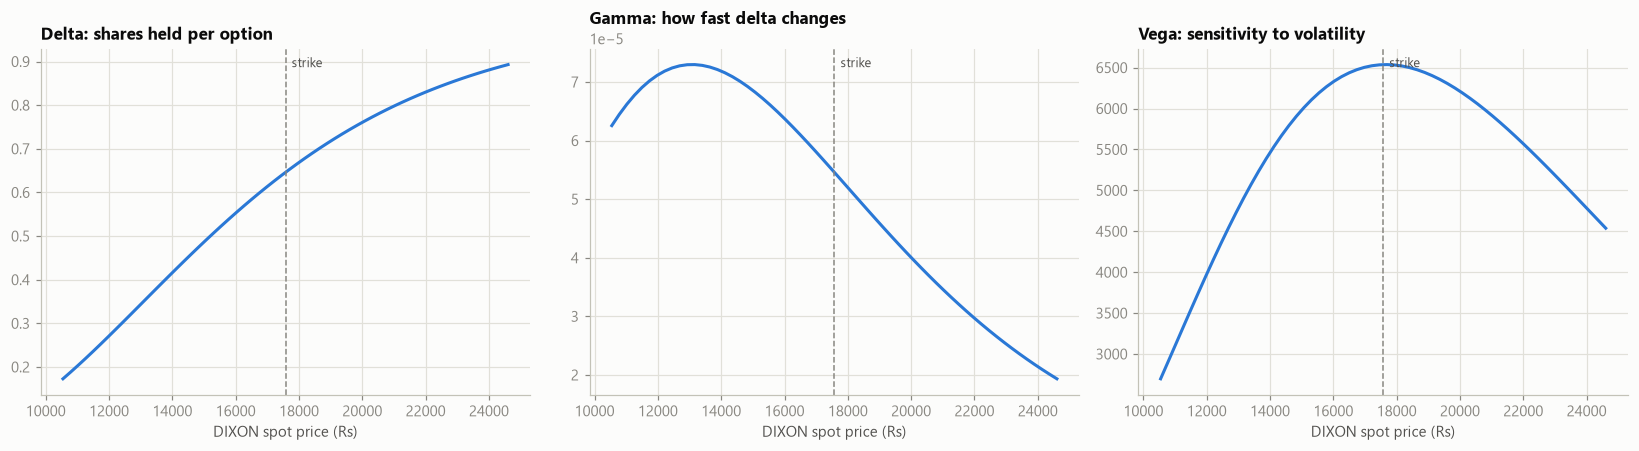

Delta runs from 0 (worthless) to 1 (behaves like the share itself).
Gamma peaks at the strike: that is where hedging costs the most, because delta is changing fastest.
Vega also peaks at the strike, and falls to zero when an option is so far in or out of the money that volatility can no longer change the outcome.


In [17]:
# --- Greeks across spot prices ---------------------------------------------
spots = np.linspace(0.6 * S0, 1.4 * S0, 60)
curves = pd.DataFrame(
    [sim.black_scholes_greeks(s, K, T, RF, SIGMA, "call") for s in spots],
    index=spots)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, greek, title in zip(
        axes, ["delta", "gamma", "vega"],
        ["Delta: shares held per option", "Gamma: how fast delta changes",
         "Vega: sensitivity to volatility"]):
    ax.plot(spots, curves[greek], color=SERIES[0])
    ax.axvline(K, color=MUTED, linestyle="--", linewidth=1)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(f"{UNDERLYING} spot price (Rs)")
    ax.annotate("strike", (K, ax.get_ylim()[1]), xytext=(4, -12),
                textcoords="offset points", fontsize=8.5, color=INK_2)
plt.tight_layout()
plt.savefig("outputs/mc_greeks.png", dpi=200)
plt.show()

print("Delta runs from 0 (worthless) to 1 (behaves like the share itself).")
print("Gamma peaks at the strike: that is where hedging costs the most, "
      "because delta is changing fastest.")
print("Vega also peaks at the strike, and falls to zero when an option is "
      "so far in or out of the money that volatility can no longer change "
      "the outcome.")

In [18]:
# --- Asian option Greeks: simulation is the only route ---------------------
asian_greeks = sim.mc_greeks_bump(S0, K, T, RF, SIGMA, "asian_call",
                                  n_paths=100_000, n_steps=252, seed=SEED)

compare_kinds = pd.DataFrame({
    "European (exact)": {k: bs_greeks[k] for k in ["delta", "gamma", "vega"]},
    "Asian (simulated)": {k: asian_greeks[k] for k in ["delta", "gamma", "vega"]},
})
display(compare_kinds.style.format("{:,.4f}"))

print("The Asian option has lower delta and lower vega, because the average "
      "responds less than the final price to both the spot and to volatility.")
print("Its gamma is higher at the money: the effective volatility of the "
      "average is smaller, so the payoff turns more sharply around the strike.")

,European (exact),Asian (simulated)
delta,0.6460,0.5772
gamma,0.0001,0.0001
vega,"6,536.4476","3,810.0931"


The Asian option has lower delta and lower vega, because the average responds less than the final price to both the spot and to volatility.
Its gamma is higher at the money: the effective volatility of the average is smaller, so the payoff turns more sharply around the strike.


## 9. Hedging with a protective put

A protective put means holding the portfolio and buying puts on it. The put pays out when the portfolio falls, which cuts off the left tail of the distribution. The premium is paid whether or not it is ever needed.

Two ways of doing it, and the comparison is the real content of this section:

| | Single-stock puts | One Nifty put, sized by beta |
|---|---|---|
| **What is bought** | a put on each of the eight stocks | one index put, notional = $\beta \times$ portfolio value |
| **Protection** | matches the holdings exactly | only pays if the *index* falls |
| **Cost** | high | low |
| **Risk left over** | none of consequence | **basis risk** |

Why the index put is so much cheaper comes down to volatility: an at-the-money put costs roughly $0.4\,\sigma\sqrt{T}$ of the notional, so premium scales with volatility. The Nifty's volatility is far below that of any single stock in this basket, because diversification across 50 stocks has already removed the stock-specific risk. Buying eight separate puts also means buying more protection than the portfolio needs — each one pays when *its* stock falls, even if the portfolio as a whole is fine. An option on a sum is always cheaper than a sum of options on the parts.

**Basis risk** is what the index hedge leaves behind. Notebook 1 found that this basket has a low correlation with the Nifty (it rose 55% while the index fell 6%). A hedge that pays only when the index falls may therefore pay nothing in exactly the scenario that hurts this portfolio.

**Financing convention:** the premium is borrowed at the risk-free rate and repaid at expiry, so the full amount stays invested and the cost appears as $\text{premium} \times e^{rT}$ at the end. This keeps the hedged and unhedged portfolios directly comparable.

In [19]:
HEDGED = "Max Sharpe"           # the portfolio being insured
s_hedged = sims[HEDGED]
w_hedged = PORTFOLIOS[HEDGED]

beta_p = sim.portfolio_beta(w_hedged, betas)
nifty_vol = float(np.sqrt(Sigma_all.loc["NIFTY", "NIFTY"]))
stock_vols = pd.Series(np.sqrt(np.diag(Sigma)), index=Sigma.columns)

print(f"Portfolio      : {HEDGED},  Rs {INITIAL_VALUE:,} invested")
print(f"Portfolio beta : {beta_p:.2f}  ->  index hedge notional "
      f"Rs {beta_p*INITIAL_VALUE:,.0f}")
print(f"Nifty vol      : {nifty_vol:.1%}")
print(f"Stock vols     : {stock_vols[w_hedged[w_hedged > 0.01].index].round(2).to_dict()}")

# Build the two hedges at the same strike (5% out of the money).
hedge_stocks = sim.single_stock_put_hedge(s_hedged, Sigma_all, w_hedged,
                                          STRIKE_PCT, HORIZON_YEARS, RF)
hedge_index = sim.index_put_hedge(s_hedged, "NIFTY", nifty_vol, beta_p,
                                  STRIKE_PCT, HORIZON_YEARS, RF)

print(f"\nPremium, single-stock puts : Rs {hedge_stocks['premium']:>10,.0f}  "
      f"({hedge_stocks['premium']/INITIAL_VALUE:.2%} of the portfolio)")
print(f"Premium, one Nifty put     : Rs {hedge_index['premium']:>10,.0f}  "
      f"({hedge_index['premium']/INITIAL_VALUE:.2%} of the portfolio)")
print(f"The index hedge costs "
      f"{hedge_stocks['premium']/hedge_index['premium']:.0f}x less.")

Portfolio      : Max Sharpe,  Rs 1,000,000 invested
Portfolio beta : 1.04  ->  index hedge notional Rs 1,035,701
Nifty vol      : 13.3%
Stock vols     : {'KAYNES': 0.5, 'DIXON': 0.39, 'NETWEB': 0.52, 'E2E': 0.54}

Premium, single-stock puts : Rs    123,288  (12.33% of the portfolio)
Premium, one Nifty put     : Rs     12,743  (1.27% of the portfolio)
The index hedge costs 10x less.


,Premium (% of value),Mean return,Median return,VaR 95%,CVaR 95%,5th percentile,P(loss),Worst case
Unhedged,0.00%,13.65%,7.03%,37.82%,45.13%,-37.82%,41.77%,-68.42%
Single-stock puts,12.33%,11.92%,2.38%,18.22%,18.22%,-18.22%,46.40%,-18.22%
Nifty put (beta 1.04),1.27%,12.91%,6.17%,37.61%,44.63%,-37.61%,42.71%,-69.78%


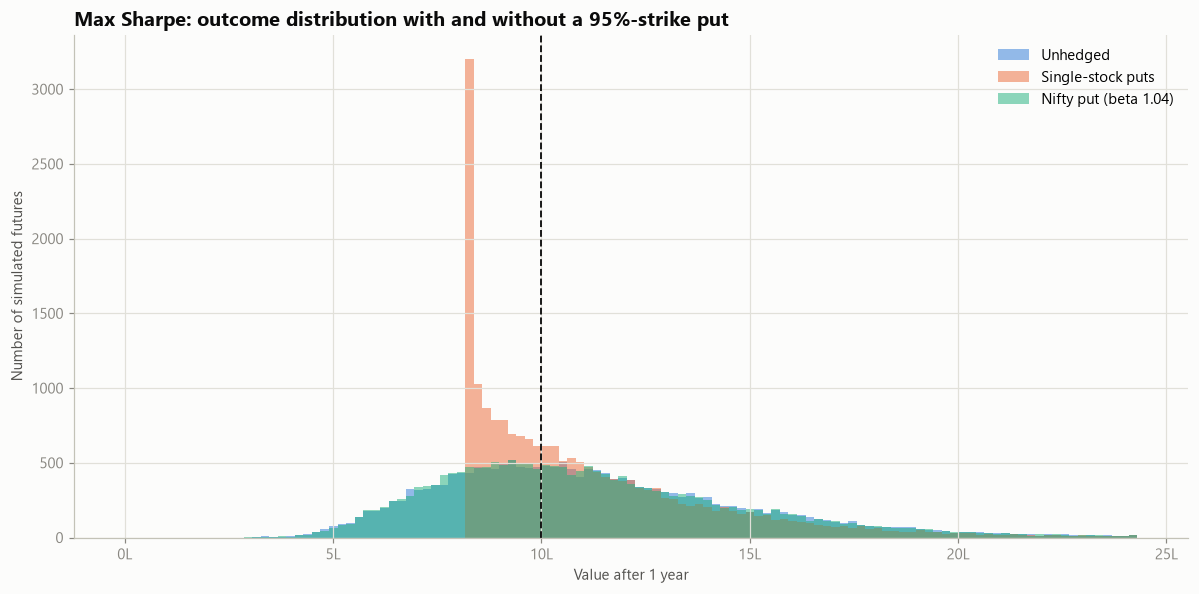

In [20]:
comparison = sim.compare_hedges(s_hedged, [hedge_stocks, hedge_index],
                                RF, HORIZON_YEARS, confidence=0.95)
display(comparison.style.format("{:.2%}"))

# Distribution of outcomes with and without each hedge.
fig, ax = plt.subplots(figsize=(11, 5.5))
outcomes = {
    "Unhedged": s_hedged["values"][:, -1],
    hedge_stocks["label"]: sim.hedged_outcomes(s_hedged, hedge_stocks, RF, HORIZON_YEARS),
    hedge_index["label"]: sim.hedged_outcomes(s_hedged, hedge_index, RF, HORIZON_YEARS),
}
bins = np.linspace(0, np.percentile(outcomes["Unhedged"], 99), 120)
for i, (label, values) in enumerate(outcomes.items()):
    ax.hist(values, bins=bins, color=SERIES[i], alpha=0.5, label=label)

ax.axvline(INITIAL_VALUE, color=INK, linestyle="--", linewidth=1.2)
ax.set_title(f"{HEDGED}: outcome distribution with and without a "
             f"{STRIKE_PCT:.0%}-strike put")
ax.set_xlabel("Value after 1 year")
ax.set_ylabel("Number of simulated futures")
rupee_axis(ax, "x")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/mc_hedge_distributions.png", dpi=200)
plt.show()

### 9.1 Choosing a strike

The strike sets the deductible on the insurance. A 100% strike protects from the first rupee of loss and costs the most; an 85% strike lets the portfolio fall 15% before paying anything, and costs far less.

The table below prices both hedges at several strikes. The number to watch is not the premium alone but **how much CVaR falls per rupee of premium** — protection is only worth buying if it removes more tail risk than it costs in expected return.

In [21]:
strike_rows = []
for strike in [0.85, 0.90, 0.95, 1.00]:
    h_stock = sim.single_stock_put_hedge(s_hedged, Sigma_all, w_hedged,
                                         strike, HORIZON_YEARS, RF)
    h_index = sim.index_put_hedge(s_hedged, "NIFTY", nifty_vol, beta_p,
                                  strike, HORIZON_YEARS, RF)
    base_cvar = sim.conditional_value_at_risk(s_hedged["values"][:, -1],
                                              INITIAL_VALUE, 0.95)
    for hedge in (h_stock, h_index):
        terminal = sim.hedged_outcomes(s_hedged, hedge, RF, HORIZON_YEARS)
        cvar = sim.conditional_value_at_risk(terminal, INITIAL_VALUE, 0.95)
        premium_pct = hedge["premium"] / INITIAL_VALUE
        strike_rows.append({
            "Hedge": hedge["label"],
            "Strike": strike,
            "Premium": premium_pct,
            "CVaR 95%": cvar,
            "CVaR reduction": base_cvar - cvar,
            "Reduction per rupee of premium": (base_cvar - cvar) / premium_pct,
            "Mean return": float(terminal.mean() / INITIAL_VALUE - 1),
        })

strikes = pd.DataFrame(strike_rows)
display(strikes.style.format({"Strike": "{:.0%}", "Premium": "{:.2%}",
                              "CVaR 95%": "{:.2%}", "CVaR reduction": "{:.2%}",
                              "Reduction per rupee of premium": "{:.2f}",
                              "Mean return": "{:.2%}"}))

,Hedge,Strike,Premium,CVaR 95%,CVaR reduction,Reduction per rupee of premium,Mean return
0,Single-stock puts,85%,8.22%,23.81%,21.31%,2.59,12.40%
1,Nifty put (beta 1.04),85%,0.20%,44.97%,0.16%,0.78,13.51%
2,Single-stock puts,90%,10.16%,20.90%,24.23%,2.38,12.17%
3,Nifty put (beta 1.04),90%,0.55%,44.82%,0.31%,0.56,13.30%
4,Single-stock puts,95%,12.33%,18.22%,26.91%,2.18,11.92%
5,Nifty put (beta 1.04),95%,1.27%,44.63%,0.50%,0.39,12.91%
6,Single-stock puts,100%,14.71%,15.77%,29.36%,2.00,11.66%
7,Nifty put (beta 1.04),100%,2.52%,44.46%,0.67%,0.27,12.32%


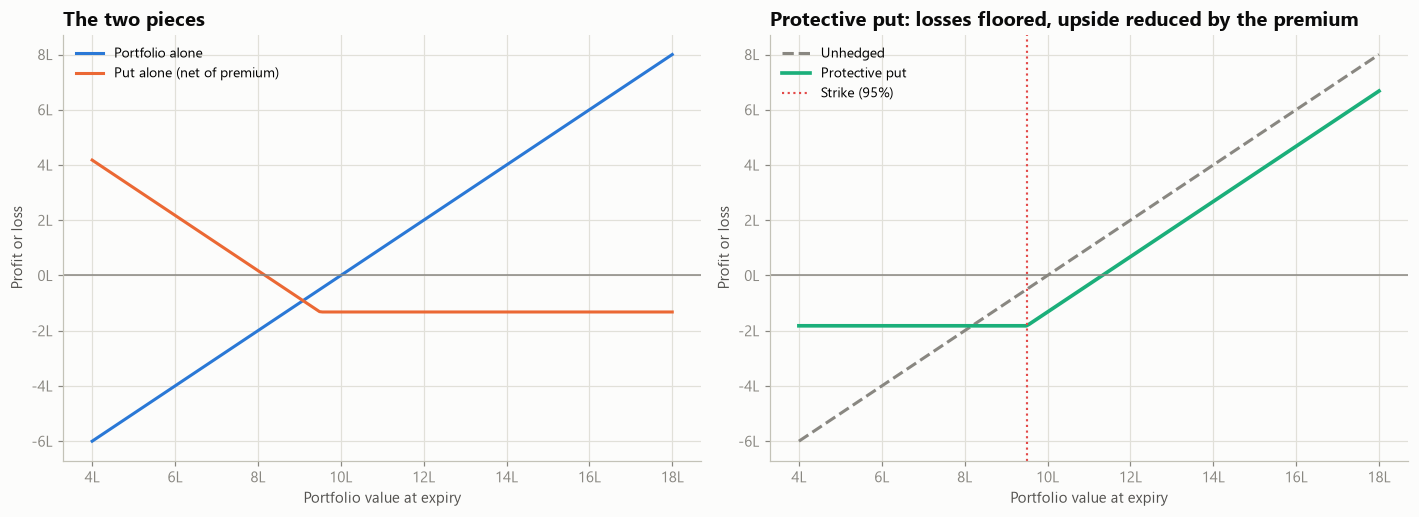

In [22]:
# --- Payoff diagrams --------------------------------------------------------
# What each strategy is worth at expiry, for any given portfolio outcome.
# These are the textbook hockey-stick charts, drawn from our own numbers.
portfolio_outcomes = np.linspace(0.4, 1.8, 200) * INITIAL_VALUE
growth = portfolio_outcomes / INITIAL_VALUE

premium_cost = hedge_stocks["premium"] * np.exp(RF * HORIZON_YEARS)
put_payoff = INITIAL_VALUE * np.maximum(STRIKE_PCT - growth, 0.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# Left: the components.
ax = axes[0]
ax.plot(portfolio_outcomes, portfolio_outcomes - INITIAL_VALUE,
        color=SERIES[0], label="Portfolio alone")
ax.plot(portfolio_outcomes, put_payoff - premium_cost, color=SERIES[1],
        label="Put alone (net of premium)")
ax.axhline(0, color=MUTED, linewidth=1)
ax.set_title("The two pieces")
ax.legend(fontsize=9)

# Right: the combination.
ax = axes[1]
ax.plot(portfolio_outcomes, portfolio_outcomes - INITIAL_VALUE,
        color=MUTED, linestyle="--", label="Unhedged")
ax.plot(portfolio_outcomes, portfolio_outcomes + put_payoff - premium_cost
        - INITIAL_VALUE, color=SERIES[2], linewidth=2.4,
        label="Protective put")
ax.axhline(0, color=MUTED, linewidth=1)
ax.axvline(STRIKE_PCT * INITIAL_VALUE, color=SERIES[7], linestyle=":",
           linewidth=1.4, label=f"Strike ({STRIKE_PCT:.0%})")
ax.set_title("Protective put: losses floored, upside reduced by the premium")
ax.legend(fontsize=9)

for ax in axes:
    ax.set_xlabel("Portfolio value at expiry")
    ax.set_ylabel("Profit or loss")
    rupee_axis(ax, "x"); rupee_axis(ax, "y")
plt.tight_layout()
plt.savefig("outputs/mc_payoff_diagrams.png", dpi=200)
plt.show()

## 10. Delta hedging: what Black-Scholes assumes, and what actually happens

Black-Scholes derives its price by assuming the seller rehedges **continuously**, which makes the position riskless. Nobody can trade continuously. This section simulates a trader who sells a one-year at-the-money call and rehedges at fixed intervals, to measure what that approximation costs.

The mechanics per path:

1. Sell the option, receive the premium, put the cash on deposit at $r$.
2. Buy $\Delta$ shares, borrowing to do so.
3. At each rebalancing date recompute $\Delta$ with the time remaining and adjust the holding.
4. At expiry sell the shares, pay the option's payoff, and see what is left. Under perfect continuous hedging that remainder would be exactly zero.

Two results to expect, both worth being able to state from memory:

- **Rehedging error shrinks as $1/\sqrt{n}$** in the number of rehedges (Boyle & Emanuel, 1980). Hedging twice as often only cuts the error by about 30%, and in reality transaction costs would rise instead.
- **The P&L depends on realised versus priced volatility.** Sell at 40% and realise 25%, and the hedge costs less than the premium collected. The profit accrues through gamma — the daily rehedging buys low and sells high — which is why traders call this being short gamma, or gamma scalping.

,Rebalance every (days),Number of rebalances,Mean P&L (% of premium),Std dev (% of premium),5th percentile,95th percentile,Worst path
0,1,252,-0.00%,4.66%,-7.52%,7.78%,-25.74%
1,2,126,-0.07%,6.52%,-10.66%,10.59%,-31.55%
2,5,50,-0.00%,9.95%,-16.45%,16.17%,-56.49%
3,21,12,0.62%,19.98%,-32.71%,32.75%,-89.23%
4,63,4,0.75%,34.42%,-56.88%,55.60%,-226.11%


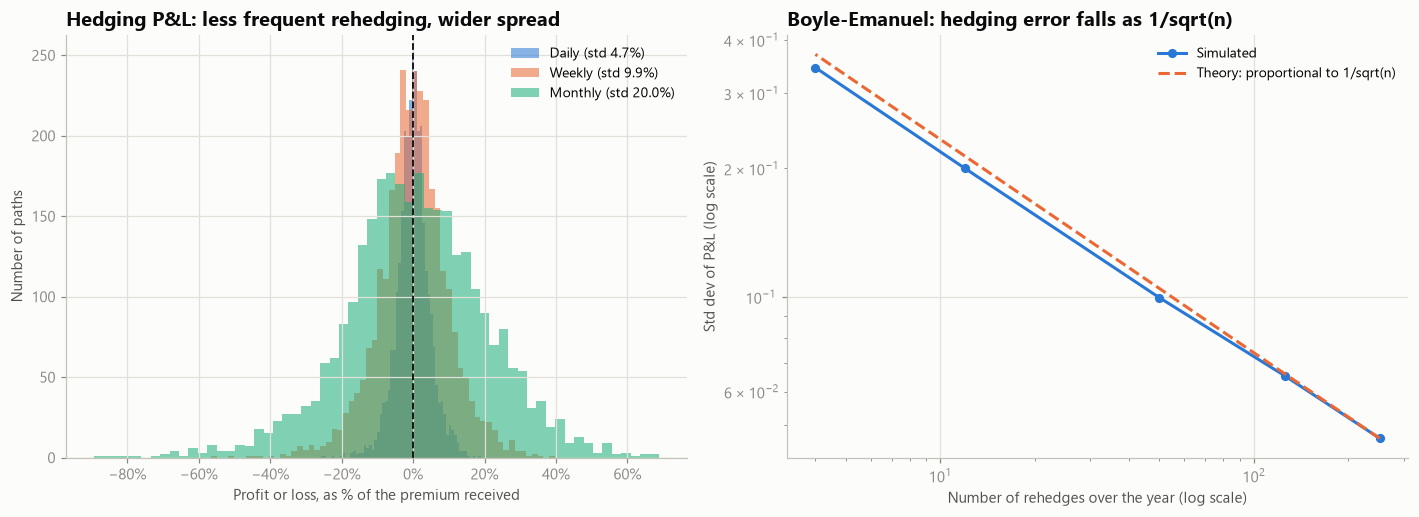

In [23]:
# Hedge a one-year at-the-money call on the same underlying.
freq_table = sim.hedging_error_study(S0, K, T, RF, SIGMA,
                                     frequencies=(1, 2, 5, 21, 63),
                                     n_paths=3_000, seed=SEED)
display(freq_table.style.format({
    "Mean P&L (% of premium)": "{:.2%}", "Std dev (% of premium)": "{:.2%}",
    "5th percentile": "{:.2%}", "95th percentile": "{:.2%}",
    "Worst path": "{:.2%}"}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# Left: P&L distributions at three frequencies.
ax = axes[0]
for i, freq in enumerate([1, 5, 21]):
    res = sim.delta_hedge_simulation(S0, K, T, RF, SIGMA, rebalance_every=freq,
                                     n_paths=3_000, seed=SEED)
    label = {1: "Daily", 5: "Weekly", 21: "Monthly"}[freq]
    ax.hist(res["pnl_pct_of_premium"], bins=60, color=SERIES[i], alpha=0.55,
            label=f"{label} (std {res['pnl_pct_of_premium'].std():.1%})")
ax.axvline(0, color=INK, linestyle="--", linewidth=1.2)
ax.set_title("Hedging P&L: less frequent rehedging, wider spread")
ax.set_xlabel("Profit or loss, as % of the premium received")
ax.set_ylabel("Number of paths")
pct_axis(ax, "x")
ax.legend(fontsize=9)

# Right: the 1/sqrt(n) law.
ax = axes[1]
ax.plot(freq_table["Number of rebalances"], freq_table["Std dev (% of premium)"],
        color=SERIES[0], marker="o", markersize=5, label="Simulated")
reference = (freq_table["Std dev (% of premium)"].iloc[0]
             * np.sqrt(freq_table["Number of rebalances"].iloc[0]
                       / freq_table["Number of rebalances"]))
ax.plot(freq_table["Number of rebalances"], reference, color=SERIES[1],
        linestyle="--", label="Theory: proportional to 1/sqrt(n)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Number of rehedges over the year (log scale)")
ax.set_ylabel("Std dev of P&L (log scale)")
ax.set_title("Boyle-Emanuel: hedging error falls as 1/sqrt(n)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("outputs/mc_delta_hedge.png", dpi=200)
plt.show()

In [24]:
# --- Selling volatility: priced vs realised --------------------------------
# The option is always SOLD at SIGMA. Only the stock's actual volatility changes.
vol_rows = []
for realised in [0.6 * SIGMA, 0.8 * SIGMA, SIGMA, 1.2 * SIGMA, 1.4 * SIGMA]:
    res = sim.delta_hedge_simulation(S0, K, T, RF, SIGMA,
                                     sigma_realised=realised,
                                     rebalance_every=1, n_paths=3_000,
                                     seed=SEED)
    pnl = res["pnl_pct_of_premium"]
    vol_rows.append({
        "Sold at (implied)": SIGMA,
        "Realised vol": realised,
        "Mean P&L (% of premium)": float(pnl.mean()),
        "Std dev": float(pnl.std(ddof=1)),
        "P(loss)": float((pnl < 0).mean()),
    })

display(pd.DataFrame(vol_rows).style.format({
    "Sold at (implied)": "{:.1%}", "Realised vol": "{:.1%}",
    "Mean P&L (% of premium)": "{:+.1%}", "Std dev": "{:.1%}",
    "P(loss)": "{:.0%}"}))

print("Selling an option is a bet on volatility, not on direction. The "
      "delta hedge removes the directional exposure; what is left is the "
      "difference between the volatility charged and the volatility that "
      "actually occurs.")

,Sold at (implied),Realised vol,Mean P&L (% of premium),Std dev,P(loss)
0,38.8%,23.3%,+33.4%,9.9%,0%
1,38.8%,31.0%,+16.8%,6.8%,0%
2,38.8%,38.8%,-0.0%,4.7%,50%
3,38.8%,46.5%,-16.7%,8.9%,100%
4,38.8%,54.3%,-33.2%,16.2%,100%


Selling an option is a bet on volatility, not on direction. The delta hedge removes the directional exposure; what is left is the difference between the volatility charged and the volatility that actually occurs.


## 11. Conclusions

_Based on data to 16 Sep 2026, with expected returns from the CAPM. Exact figures move if the data is refreshed or the drift assumption is changed in section 3._

1. **The drift assumption dominates every risk number.** Simulating with the training-period averages implies an 84% expected return for the Max Sharpe portfolio and makes losses look unlikely; the CAPM implies about 14% for the same portfolio and roughly a 40% chance of losing money over a year. The weights, the covariance matrix and the code are identical in both cases. This is Chopra & Ziemba's result showing up in practice: errors in expected returns do far more damage than errors in variances.

2. **GBM understates the tails, and the backtest shows where.** One-day VaR is close to the historical figure, but the ten-day 99% VaR is materially too small: real returns cluster their bad days together, which a model of independent normal shocks cannot produce. In the test period the 95% VaR was breached more often than the 5% of days it allows.

3. **VaR and CVaR tell different stories, and CVaR is the more useful one.** For the Max Sharpe portfolio the 95% VaR is near 38%, while the average loss *given* a breach is around 45%. Any measure that stops at the threshold hides that gap.

4. **Monte Carlo matches Black-Scholes, which is the licence to use it elsewhere.** With 500,000 paths the simulated European call sits within a few paise of the closed-form price, the error falls as $1/\sqrt{N}$ on a straight log-log line, and the simulated Greeks match the analytic ones once common random numbers are used. Only then is it reasonable to trust the same engine on the Asian option, where no formula exists.

5. **Hedging cost is driven by volatility, and the cheap hedge is cheap for a reason.** Puts on the eight individual stocks cost about 12% of the portfolio and floor the loss almost completely. A beta-sized Nifty put costs roughly 1%, but it barely moves VaR or CVaR for this portfolio: the basket's correlation with the index is too low for the index to be a reliable proxy. That gap *is* basis risk, and it shows why hedging with the cheapest available instrument can amount to paying a premium for very little protection.

6. **Delta hedging works, with a measurable cost of discretisation.** Rehedging daily leaves a P&L spread of a few percent of the premium; monthly rehedging roughly quadruples it, following the $1/\sqrt{n}$ law. The direction of the stock barely matters, which is the whole point of the hedge: what remains is the bet on volatility.

## Limitations

- **Normal returns.** GBM has no fat tails, no volatility clustering and no jumps. Student-t innovations, a GARCH volatility process or a jump-diffusion model would all address this, at the cost of more parameters to estimate and defend.
- **Constant volatility and correlation.** Both are estimated once on the training window and then held fixed. In a crash both rise together, which is exactly when a hedge is needed.
- **Historical volatility in place of implied.** Free implied-volatility data for NSE options is not readily available. Option prices here therefore reflect past volatility, not what the market is charging.
- **European exercise, no dividends, no transaction costs, no taxes, and perfect divisibility of index puts.**
- **One estimation window.** A rolling-window study would show how much the conclusions depend on the particular two years used.
- **Selection bias remains.** The basket was chosen in 2026 with knowledge of the AI theme, a limitation inherited from notebook 1.

## References

- Boyle, P. & Emanuel, D. (1980). Discretely Adjusted Option Hedges. *Journal of Financial Economics*, 8(3), 259-282.
- Black, F. & Scholes, M. (1973). The Pricing of Options and Corporate Liabilities. *Journal of Political Economy*, 81(3), 637-654.
- Boyle, P. (1977). Options: A Monte Carlo Approach. *Journal of Financial Economics*, 4(3), 323-338.
- Chopra, V. & Ziemba, W. (1993). The Effect of Errors in Means, Variances, and Covariances on Optimal Portfolio Choice. *Journal of Portfolio Management*, 19(2), 6-11.
- Glasserman, P. (2003). *Monte Carlo Methods in Financial Engineering*. Springer.
- Jorion, P. (2006). *Value at Risk: The New Benchmark for Managing Financial Risk*. 3rd ed. McGraw-Hill.
- Basel Committee on Banking Supervision (2019). *Minimum Capital Requirements for Market Risk*.